# View_History × 재결제 분석
많이 본 영화를 시청한 사람들이 재결제를 했는지 분석합니다.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import rcParams
from pathlib import Path

rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False

DATA = Path('../data')

vh  = pd.read_csv(DATA / 'View_History.csv')
mem = pd.read_csv(DATA / 'Membership.csv')
um  = pd.read_csv(DATA / 'User_Mapping.csv')
mov = pd.read_csv(DATA / 'Movie_Master.csv')

# 타겟 인코딩: repurchase O→1, NaN→0
mem['repurchase_yn'] = mem['repurchase'].apply(lambda x: 1 if x == 'O' else 0)

print(f'View_History: {len(vh):,}행')
print(f'Membership  : {len(mem):,}행')
print(f'User_Mapping: {len(um):,}행')
print(f'Movie_Master: {len(mov):,}행')

View_History: 106,205행
Membership  : 18,183행
User_Mapping: 19,877행
Movie_Master: 14,018행


In [12]:
# ── 조인: View_History → User_Mapping → Membership ─────────────
# USER_ID → uid(user_no) → repurchase
vh_um = vh.merge(um, on='USER_ID', how='inner')          # uid 추가
vh_mem = vh_um.merge(
    mem[['user_no', 'repurchase_yn']],
    left_on='uid', right_on='user_no', how='inner'
)                                                         # repurchase 추가

# MOVIE_ID → TITLE
vh_mem = vh_mem.merge(mov[['MOVIE_ID', 'TITLE']], on='MOVIE_ID', how='left')

print(f'조인 결과: {len(vh_mem):,}행')
print(f'유니크 유저: {vh_mem["USER_ID"].nunique():,}명')
print(f'유니크 영화: {vh_mem["MOVIE_ID"].nunique():,}편')
vh_mem.head(3)

조인 결과: 108,788행
유니크 유저: 14,892명
유니크 영화: 5,196편


,USER_ID,MOVIE_ID,DURATION,WATCH_DAY,WATCH_SEQ,uid,user_no,repurchase_yn,TITLE
0,0,4243,1,20210314,1,ce6c11de3c6c21a993965a45943bce46f068b56869feca...,ce6c11de3c6c21a993965a45943bce46f068b56869feca...,1,코마
1,0,4243,111,20210314,2,ce6c11de3c6c21a993965a45943bce46f068b56869feca...,ce6c11de3c6c21a993965a45943bce46f068b56869feca...,1,코마
2,0,1860,101,20210319,1,ce6c11de3c6c21a993965a45943bce46f068b56869feca...,ce6c11de3c6c21a993965a45943bce46f068b56869feca...,1,이퀼리브리엄


In [13]:
# ── 영화별 집계 ────────────────────────────────────────────────
# 동일 유저가 같은 영화를 여러 번 쪼개 시청(WATCH_SEQ>1)할 수 있으므로
# 유저 단위로 먼저 deduplicate 후 집계
user_movie = (
    vh_mem.groupby(['MOVIE_ID', 'TITLE', 'USER_ID'])
    .agg(
        total_duration=('DURATION', 'sum'),
        repurchase_yn =('repurchase_yn', 'first'),   # 유저당 1개 값
    )
    .reset_index()
)

movie_stats = (
    user_movie.groupby(['MOVIE_ID', 'TITLE'])
    .agg(
        viewer_count   =('USER_ID',       'count'),   # 시청자 수
        repurchase_cnt =('repurchase_yn',  'sum'),     # 재결제자 수
        avg_duration   =('total_duration', 'mean'),   # 평균 시청 시간(분)
    )
    .reset_index()
)

movie_stats['repurchase_rate'] = (
    movie_stats['repurchase_cnt'] / movie_stats['viewer_count']
).round(4)

movie_stats = movie_stats.sort_values('viewer_count', ascending=False).reset_index(drop=True)

print(f'집계 완료: {len(movie_stats)}편')
movie_stats.head(20)

집계 완료: 5196편


,MOVIE_ID,TITLE,viewer_count,repurchase_cnt,avg_duration,repurchase_rate
0,2198,어니스트씨프,1096,739,66.720803,0.6743
1,5184,궁(2013),1086,706,89.234807,0.6501
2,1900,죽여주는여자(2016),1079,691,74.101946,0.6404
3,1616,마스터(2016),972,657,103.910494,0.6759
4,4201,무뢰한,892,591,70.863229,0.6626
5,2170,소울,813,534,55.212792,0.6568
6,6654,뱅가드,792,497,77.159091,0.6275
7,13215,론서바이버,738,491,87.227642,0.6653
8,5038,오네긴,705,461,48.923404,0.6539
9,10508,최후의카운트다운,679,445,70.500736,0.6554


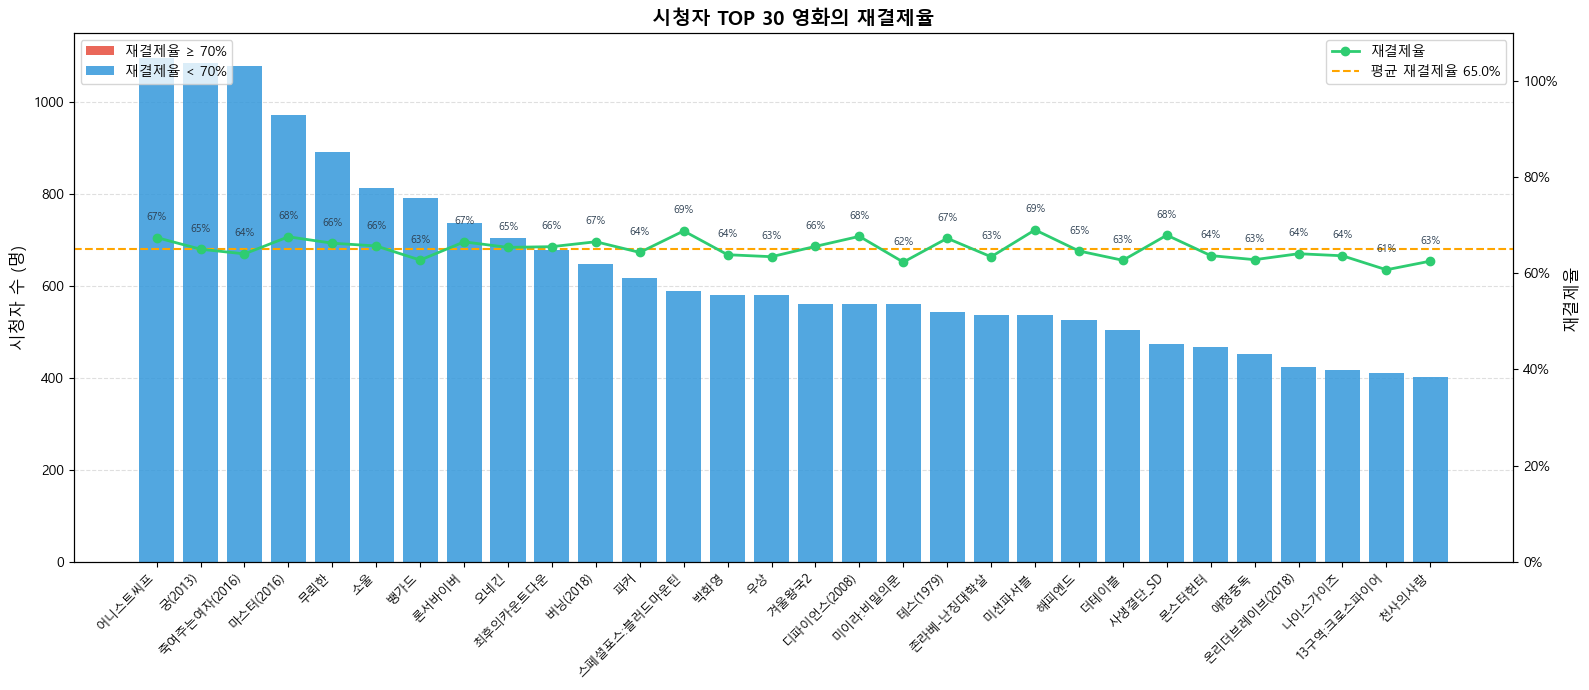

저장: view_repurchase_top30.png


In [14]:
# ── 시각화 1: 시청자 많은 TOP 30 + 재결제율 ───────────────────
TOP_N = 30
top = movie_stats.head(TOP_N).copy()

# 제목이 너무 길면 자르기
top['label'] = top['TITLE'].str[:15]

fig, ax1 = plt.subplots(figsize=(16, 7))

colors = ['#e74c3c' if r >= 0.7 else '#3498db' for r in top['repurchase_rate']]
bars = ax1.bar(range(TOP_N), top['viewer_count'], color=colors, alpha=0.85, zorder=2)
ax1.set_ylabel('시청자 수 (명)', fontsize=12)
ax1.set_xticks(range(TOP_N))
ax1.set_xticklabels(top['label'], rotation=45, ha='right', fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.4, zorder=1)
ax1.set_title(f'시청자 TOP {TOP_N} 영화의 재결제율', fontsize=14, fontweight='bold')

# 재결제율 꺾은선 (우측 축)
ax2 = ax1.twinx()
ax2.plot(range(TOP_N), top['repurchase_rate'], 'o-', color='#2ecc71',
         linewidth=2, markersize=6, zorder=3, label='재결제율')
ax2.axhline(top['repurchase_rate'].mean(), color='orange', linestyle='--',
            linewidth=1.5, label=f'평균 재결제율 {top["repurchase_rate"].mean():.1%}')
ax2.set_ylabel('재결제율', fontsize=12)
ax2.set_ylim(0, 1.1)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.legend(loc='upper right', fontsize=10)

# 막대 위에 재결제율 숫자 표시
for j, (_, row) in enumerate(top.iterrows()):
    ax2.text(j, row['repurchase_rate'] + 0.03, f"{row['repurchase_rate']:.0%}",
             ha='center', va='bottom', fontsize=7.5, color='#2c3e50')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', alpha=0.85, label='재결제율 ≥ 70%'),
                   Patch(facecolor='#3498db', alpha=0.85, label='재결제율 < 70%')]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('view_repurchase_top30.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: view_repurchase_top30.png')

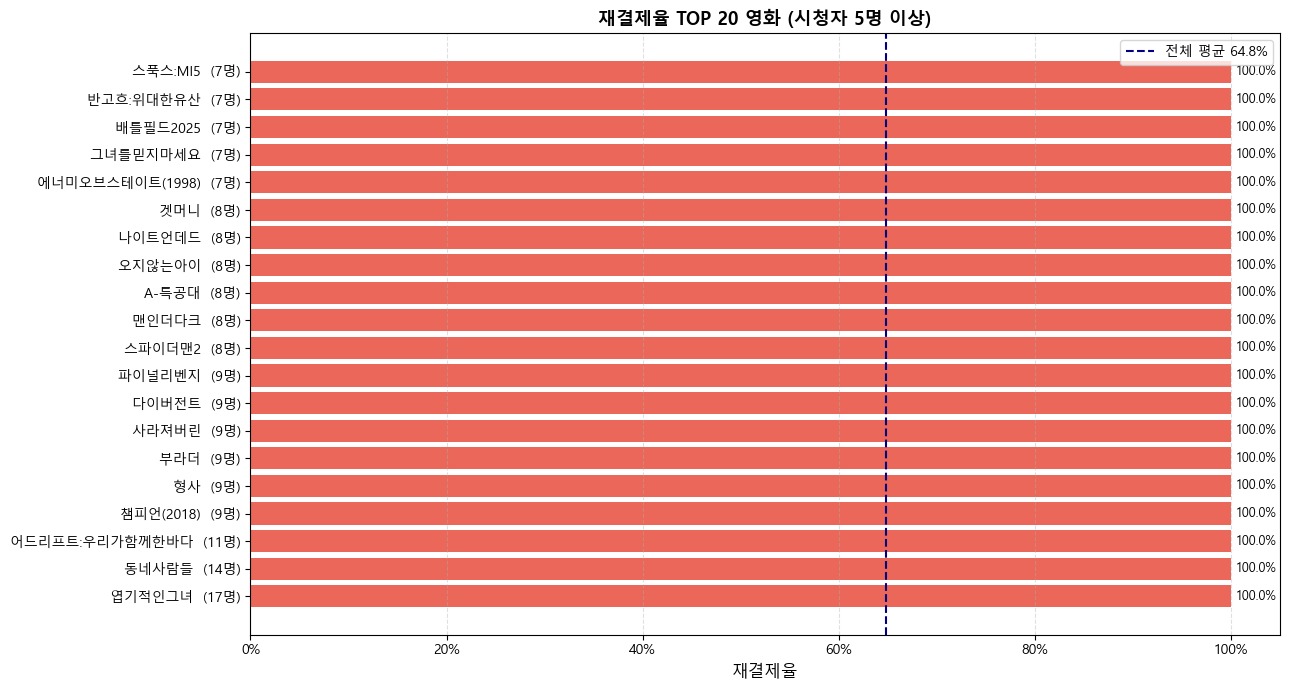

저장: view_repurchase_rate_top20.png


In [15]:
# ── 시각화 2: 재결제율 높은 TOP 20 (최소 시청자 5명 이상) ───────
MIN_VIEWERS = 5
top_rate = (
    movie_stats[movie_stats['viewer_count'] >= MIN_VIEWERS]
    .nlargest(20, 'repurchase_rate')
    .copy()
)
top_rate['label'] = top_rate['TITLE'].str[:15]

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(range(len(top_rate)), top_rate['repurchase_rate'],
               color='#e74c3c', alpha=0.85)
ax.set_yticks(range(len(top_rate)))
ax.set_yticklabels(
    [f"{r['label']}  ({int(r['viewer_count'])}명)" for _, r in top_rate.iterrows()],
    fontsize=10
)
ax.set_xlabel('재결제율', fontsize=12)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title(f'재결제율 TOP 20 영화 (시청자 {MIN_VIEWERS}명 이상)', fontsize=13, fontweight='bold')
ax.axvline(movie_stats['repurchase_rate'].mean(), color='navy', linestyle='--',
           linewidth=1.5, label=f'전체 평균 {movie_stats["repurchase_rate"].mean():.1%}')
ax.legend(fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.4)

for i, (_, row) in enumerate(top_rate.iterrows()):
    ax.text(row['repurchase_rate'] + 0.005, i, f"{row['repurchase_rate']:.1%}",
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('view_repurchase_rate_top20.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: view_repurchase_rate_top20.png')

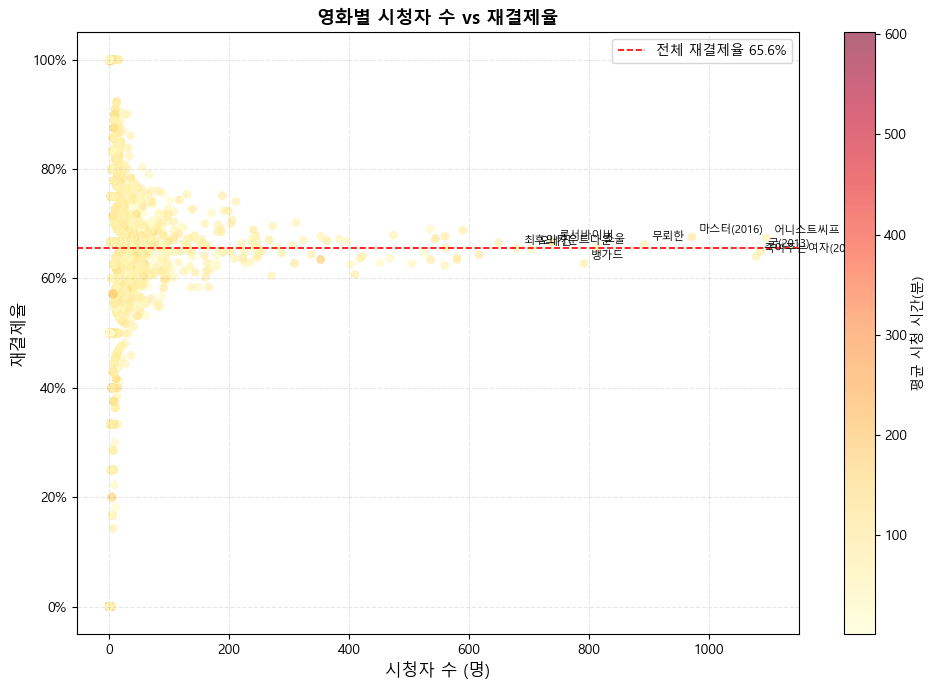

저장: view_repurchase_scatter.png


In [16]:
# ── 시각화 3: 시청자 수 vs 재결제율 산점도 ───────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(
    movie_stats['viewer_count'],
    movie_stats['repurchase_rate'],
    c=movie_stats['avg_duration'], cmap='YlOrRd',
    s=40, alpha=0.6, edgecolors='none'
)
plt.colorbar(sc, label='평균 시청 시간(분)')

# TOP 10 영화 라벨
for _, row in movie_stats.head(10).iterrows():
    ax.annotate(
        row['TITLE'][:10],
        (row['viewer_count'], row['repurchase_rate']),
        textcoords='offset points', xytext=(5, 3), fontsize=8
    )

overall_rate = mem['repurchase_yn'].mean()
ax.axhline(overall_rate, color='red', linestyle='--', linewidth=1.2,
           label=f'전체 재결제율 {overall_rate:.1%}')
ax.set_xlabel('시청자 수 (명)', fontsize=12)
ax.set_ylabel('재결제율', fontsize=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('영화별 시청자 수 vs 재결제율', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('view_repurchase_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: view_repurchase_scatter.png')

In [17]:
# ── 요약 통계 ─────────────────────────────────────────────────
overall = mem['repurchase_yn'].mean()
top_viewer_rate = movie_stats.head(10)['repurchase_rate'].mean()

print('=' * 50)
print(f'전체 재결제율              : {overall:.1%}')
print(f'시청자 TOP 10 영화 평균    : {top_viewer_rate:.1%}')
print(f'분석 영화 수               : {len(movie_stats):,}편')
print(f'분석 유저 수               : {user_movie["USER_ID"].nunique():,}명')
print('=' * 50)

print('\n[시청자 수 TOP 10]')
display(movie_stats[['TITLE','viewer_count','repurchase_cnt','repurchase_rate','avg_duration']]
        .head(10)
        .rename(columns={'viewer_count':'시청자수','repurchase_cnt':'재결제자수',
                          'repurchase_rate':'재결제율','avg_duration':'평균시청(분)'})
        .style.format({'재결제율': '{:.1%}', '평균시청(분)': '{:.0f}'})
        .bar(subset=['재결제율'], color='#e74c3c'))

# CSV 저장
movie_stats.to_csv(DATA / 'movie_repurchase_stats.csv', index=False, encoding='utf-8-sig')
print('\n저장: data/movie_repurchase_stats.csv')

전체 재결제율              : 65.6%
시청자 TOP 10 영화 평균    : 65.6%
분석 영화 수               : 5,196편
분석 유저 수               : 14,892명

[시청자 수 TOP 10]


,TITLE,시청자수,재결제자수,재결제율,평균시청(분)
0,어니스트씨프,1096,739,67.4%,67
1,궁(2013),1086,706,65.0%,89
2,죽여주는여자(2016),1079,691,64.0%,74
3,마스터(2016),972,657,67.6%,104
4,무뢰한,892,591,66.3%,71
5,소울,813,534,65.7%,55
6,뱅가드,792,497,62.7%,77
7,론서바이버,738,491,66.5%,87
8,오네긴,705,461,65.4%,49
9,최후의카운트다운,679,445,65.5%,71



저장: data/movie_repurchase_stats.csv


# 재결제율을 높이는 요인 분석\n\n## 분석 1 · 시청 행동 — 많이 볼수록 재결제하는가?

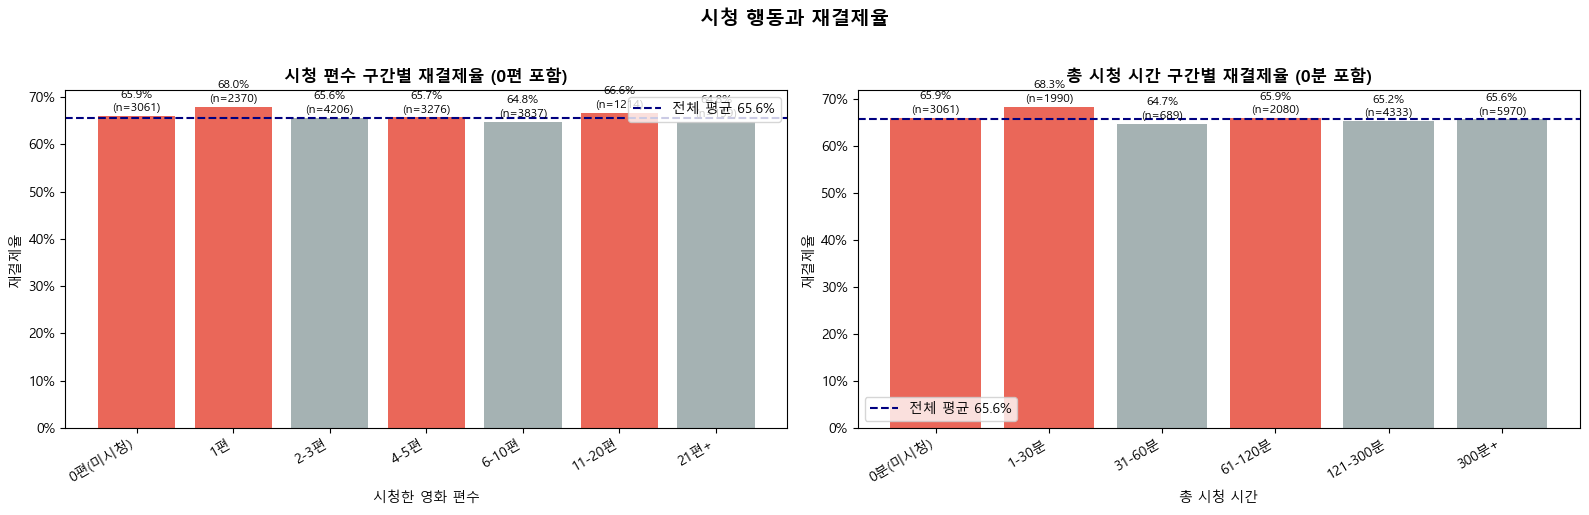

미시청 유저 재결제율: 65.9%  vs  전체 평균: 65.6%
💡 인사이트: 시청 편수/시간이 많을수록 재결제율이 높다면 → 콘텐츠 노출 확대가 핵심


In [18]:
# ── 유저별 시청 행동 집계 ──────────────────────────────────────
user_stats = (
    vh_mem.groupby(['USER_ID', 'repurchase_yn'])
    .agg(
        watch_movie_cnt  = ('MOVIE_ID',  'nunique'),
        total_duration   = ('DURATION',  'sum'),
        watch_days       = ('WATCH_DAY', 'nunique'),
    )
    .reset_index()
)

# ── 시청 이력이 없는 유저(0편)도 포함 ─────────────────────────
mem2 = mem.copy()
mem2['repurchase_yn'] = mem2['repurchase'].apply(lambda x: 1 if x == 'O' else 0)
mem_um = mem2.merge(um, left_on='user_no', right_on='uid', how='left')
watched_ids = set(user_stats['USER_ID'].unique())

zero_users = (
    mem_um[~mem_um['USER_ID'].isin(watched_ids)][['USER_ID', 'repurchase_yn']]
    .assign(watch_movie_cnt=0, total_duration=0, watch_days=0)
)

user_stats_all = pd.concat([user_stats, zero_users], ignore_index=True)

overall_rate = mem['repurchase_yn'].mean()

# 시청 편수 구간별 재결제율 (0편 포함)
bins   = [-1, 0, 1, 3, 5, 10, 20, 999]
labels = ['0편(미시청)', '1편', '2-3편', '4-5편', '6-10편', '11-20편', '21편+']
user_stats_all['watch_group'] = pd.cut(user_stats_all['watch_movie_cnt'], bins=bins, labels=labels)

group_rate = (
    user_stats_all.groupby('watch_group', observed=True)
    .agg(user_cnt=('USER_ID','count'), repurchase_rate=('repurchase_yn','mean'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 왼쪽: 시청 편수 구간별 재결제율 (0편 포함)
ax = axes[0]
colors = ['#e74c3c' if r > overall_rate else '#95a5a6' for r in group_rate['repurchase_rate']]
bars = ax.bar(group_rate['watch_group'], group_rate['repurchase_rate'], color=colors, alpha=0.85)
ax.axhline(overall_rate, color='navy', linestyle='--', linewidth=1.5, label=f'전체 평균 {overall_rate:.1%}')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('시청 편수 구간별 재결제율 (0편 포함)', fontsize=12, fontweight='bold')
ax.set_xlabel('시청한 영화 편수')
ax.set_ylabel('재결제율')
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
for bar, (_, row) in zip(bars, group_rate.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{row['repurchase_rate']:.1%}\n(n={row['user_cnt']})",
            ha='center', fontsize=8.5)

# 오른쪽: 총 시청 시간 구간별 재결제율 (0분 포함)
time_bins   = [-1, 0, 30, 60, 120, 300, 99999]
time_labels = ['0분(미시청)', '1-30분', '31-60분', '61-120분', '121-300분', '300분+']
user_stats_all['time_group'] = pd.cut(user_stats_all['total_duration'], bins=time_bins, labels=time_labels)
time_rate = (
    user_stats_all.groupby('time_group', observed=True)
    .agg(user_cnt=('USER_ID','count'), repurchase_rate=('repurchase_yn','mean'))
    .reset_index()
)

ax = axes[1]
colors2 = ['#e74c3c' if r > overall_rate else '#95a5a6' for r in time_rate['repurchase_rate']]
bars2 = ax.bar(time_rate['time_group'], time_rate['repurchase_rate'], color=colors2, alpha=0.85)
ax.axhline(overall_rate, color='navy', linestyle='--', linewidth=1.5, label=f'전체 평균 {overall_rate:.1%}')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('총 시청 시간 구간별 재결제율 (0분 포함)', fontsize=12, fontweight='bold')
ax.set_xlabel('총 시청 시간')
ax.set_ylabel('재결제율')
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
for bar, (_, row) in zip(bars2, time_rate.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{row['repurchase_rate']:.1%}\n(n={row['user_cnt']})",
            ha='center', fontsize=8.5)

plt.suptitle('시청 행동과 재결제율', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('factor1_watch_behavior.png', dpi=150, bbox_inches='tight')
plt.show()

zero_rate = group_rate[group_rate['watch_group']=='0편(미시청)']['repurchase_rate'].values[0]
print(f"미시청 유저 재결제율: {zero_rate:.1%}  vs  전체 평균: {overall_rate:.1%}")
print("💡 인사이트: 시청 편수/시간이 많을수록 재결제율이 높다면 → 콘텐츠 노출 확대가 핵심")


## 분석 2 · 장르 — 어떤 장르를 본 사람이 재결제를 더 하는가?

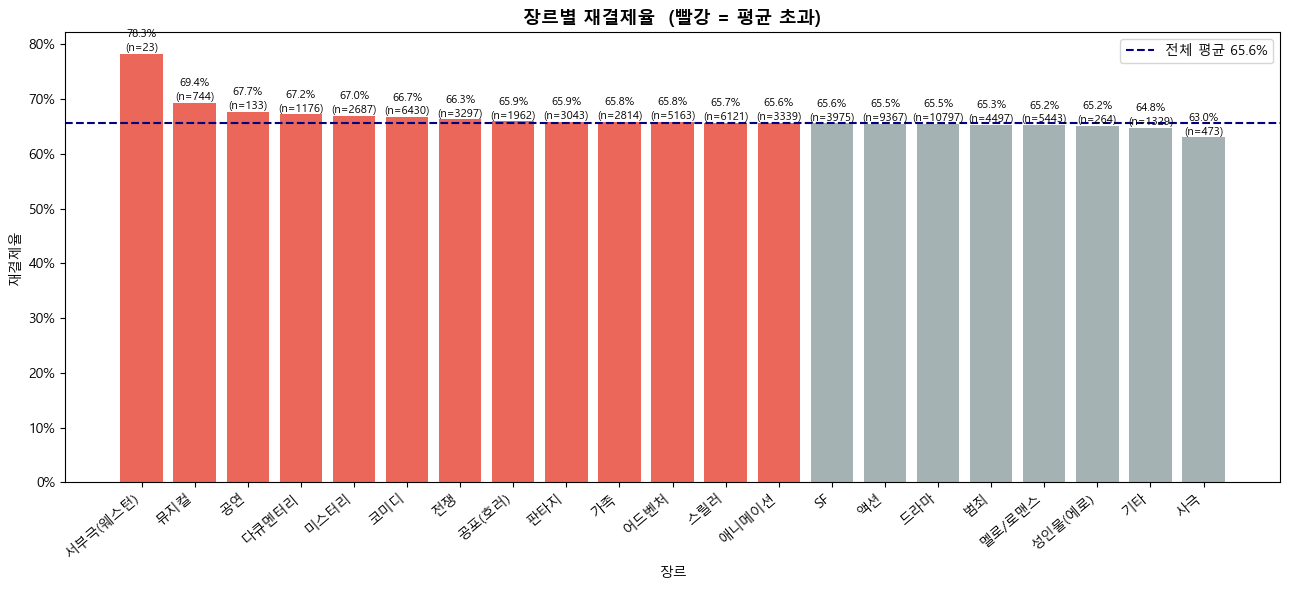


[장르별 재결제율 상위 5개]
   genre  user_cnt  repurchase_rate
서부극(웨스턴)        23         0.782609
     뮤지컬       744         0.693548
      공연       133         0.676692
   다큐멘터리      1176         0.671769
    미스터리      2687         0.669520

💡 인사이트: 재결제율 높은 장르 콘텐츠를 더 확보·추천하면 이탈 방어에 효과적


In [19]:
# KOBIS 장르 정보 활용 (Movie_Master_kobis.csv)
kobis = pd.read_csv(DATA / 'Movie_Master_kobis.csv')
kobis_genre = kobis[['MOVIE_ID', 'genreNm']].dropna(subset=['genreNm'])

# View_History에 장르 붙이기
vh_genre = vh_mem.merge(kobis_genre, on='MOVIE_ID', how='inner')

# genreNm이 "드라마|멜로/로맨스" 처럼 | 구분이므로 explode
vh_genre = vh_genre.assign(
    genre = vh_genre['genreNm'].str.split('|')
).explode('genre')
vh_genre['genre'] = vh_genre['genre'].str.strip()

# 유저-장르 단위로 deduplicate → 장르별 재결제율
user_genre = (
    vh_genre.groupby(['USER_ID', 'genre'])
    .agg(repurchase_yn=('repurchase_yn', 'first'))
    .reset_index()
)

genre_rate = (
    user_genre.groupby('genre')
    .agg(user_cnt=('USER_ID','count'), repurchase_rate=('repurchase_yn','mean'))
    .reset_index()
    .query('user_cnt >= 10')          # 샘플 너무 적은 장르 제외
    .sort_values('repurchase_rate', ascending=False)
)

fig, ax = plt.subplots(figsize=(13, 6))
colors = ['#e74c3c' if r > overall_rate else '#95a5a6' for r in genre_rate['repurchase_rate']]
bars = ax.bar(genre_rate['genre'], genre_rate['repurchase_rate'], color=colors, alpha=0.85)
ax.axhline(overall_rate, color='navy', linestyle='--', linewidth=1.5,
           label=f'전체 평균 {overall_rate:.1%}')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('장르별 재결제율  (빨강 = 평균 초과)', fontsize=13, fontweight='bold')
ax.set_xlabel('장르')
ax.set_ylabel('재결제율')
ax.legend(fontsize=10)
plt.xticks(rotation=40, ha='right')

for bar, (_, row) in zip(bars, genre_rate.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{row['repurchase_rate']:.1%}\n(n={row['user_cnt']})",
            ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('factor2_genre.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[장르별 재결제율 상위 5개]")
print(genre_rate.head(5).to_string(index=False))
print("\n💡 인사이트: 재결제율 높은 장르 콘텐츠를 더 확보·추천하면 이탈 방어에 효과적")


## 분석 3 · 프로모션·플랜·해지방어

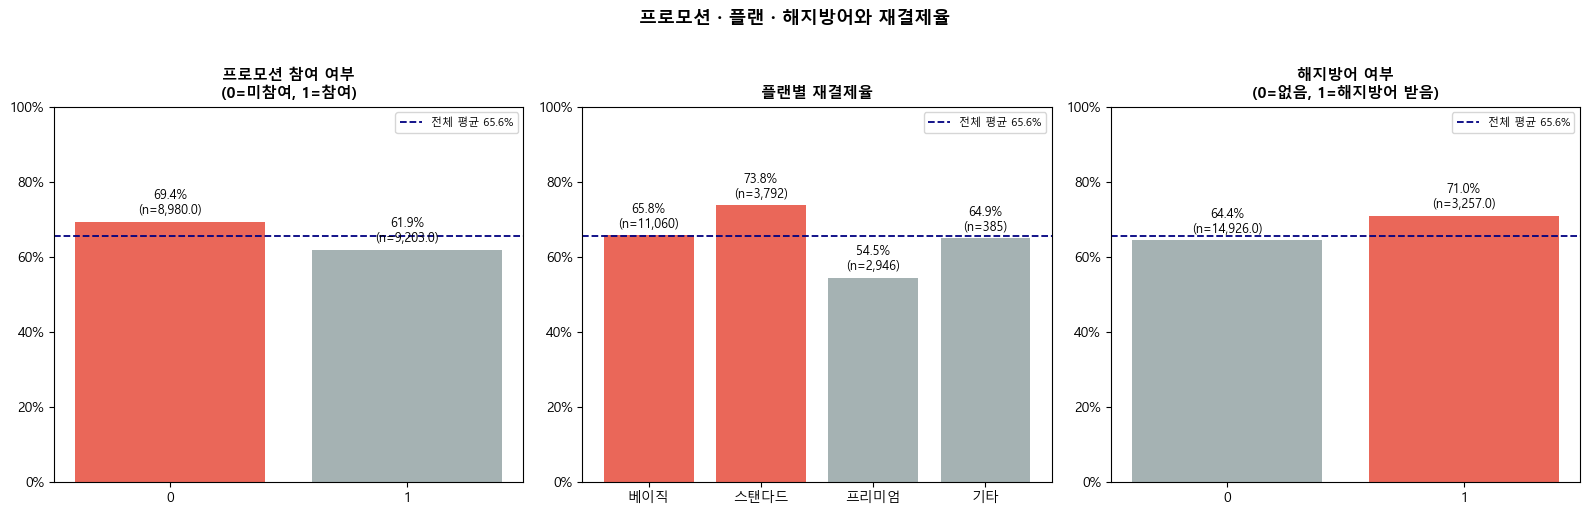

💡 인사이트 포인트:
  - 프로모션: 할인 유저가 이탈률이 높다면 → 할인 없이 유지되는 콘텐츠 강화 필요
  - 플랜: 프리미엄일수록 재결제율이 높다면 → 업셀링 전략 유효
  - 해지방어: 재결제율이 높다면 → 이탈 신호 포착 후 선제적 인센티브 제공


In [20]:
mem2 = mem.copy()
mem2['repurchase_yn']       = mem2['repurchase'].apply(lambda x: 1 if x == 'O' else 0)
mem2['promotion_yn']        = mem2['promotion_yn'].apply(lambda x: 1 if x == 'O' else 0)
mem2['is_churn_prevented']  = mem2['is_churn_prevented'].apply(lambda x: 1 if x == 'O' else 0)

# 플랜 티어 추출
plan_map = {
    'pk_1487': '베이직', 'pk_2025': '베이직', 'pk_1508': '베이직',
    'pk_1488': '스탠다드', 'pk_2026': '스탠다드', 'pk_1506': '스탠다드',
    'pk_1489': '프리미엄', 'pk_2027': '프리미엄', 'pk_1507': '프리미엄',
}
mem2['plan_tier'] = mem2['product_cd'].map(plan_map).fillna('기타')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def plot_group_bar(ax, df, col, title, order=None):
    grp = df.groupby(col)['repurchase_yn'].agg(['mean','count']).reset_index()
    grp.columns = [col, 'rate', 'cnt']
    if order:
        grp[col] = pd.Categorical(grp[col], categories=order, ordered=True)
        grp = grp.sort_values(col)
    colors = ['#e74c3c' if r > overall_rate else '#95a5a6' for r in grp['rate']]
    bars = ax.bar(grp[col].astype(str), grp['rate'], color=colors, alpha=0.85)
    ax.axhline(overall_rate, color='navy', linestyle='--', linewidth=1.3,
               label=f'전체 평균 {overall_rate:.1%}')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)
    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{row['rate']:.1%}\n(n={row['cnt']:,})",
                ha='center', fontsize=9)

# 왼쪽: 프로모션 여부
plot_group_bar(axes[0], mem2, 'promotion_yn', '프로모션 참여 여부\n(0=미참여, 1=참여)')

# 가운데: 플랜 티어
plot_group_bar(axes[1], mem2, 'plan_tier', '플랜별 재결제율',
               order=['베이직','스탠다드','프리미엄','기타'])

# 오른쪽: 해지방어 여부
plot_group_bar(axes[2], mem2, 'is_churn_prevented', '해지방어 여부\n(0=없음, 1=해지방어 받음)')

plt.suptitle('프로모션 · 플랜 · 해지방어와 재결제율', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('factor3_promo_plan.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 인사이트 포인트:")
print("  - 프로모션: 할인 유저가 이탈률이 높다면 → 할인 없이 유지되는 콘텐츠 강화 필요")
print("  - 플랜: 프리미엄일수록 재결제율이 높다면 → 업셀링 전략 유효")
print("  - 해지방어: 재결제율이 높다면 → 이탈 신호 포착 후 선제적 인센티브 제공")


## 분석 4 · 시청 이력 유무 — 영화를 아예 안 본 유저 vs 본 유저

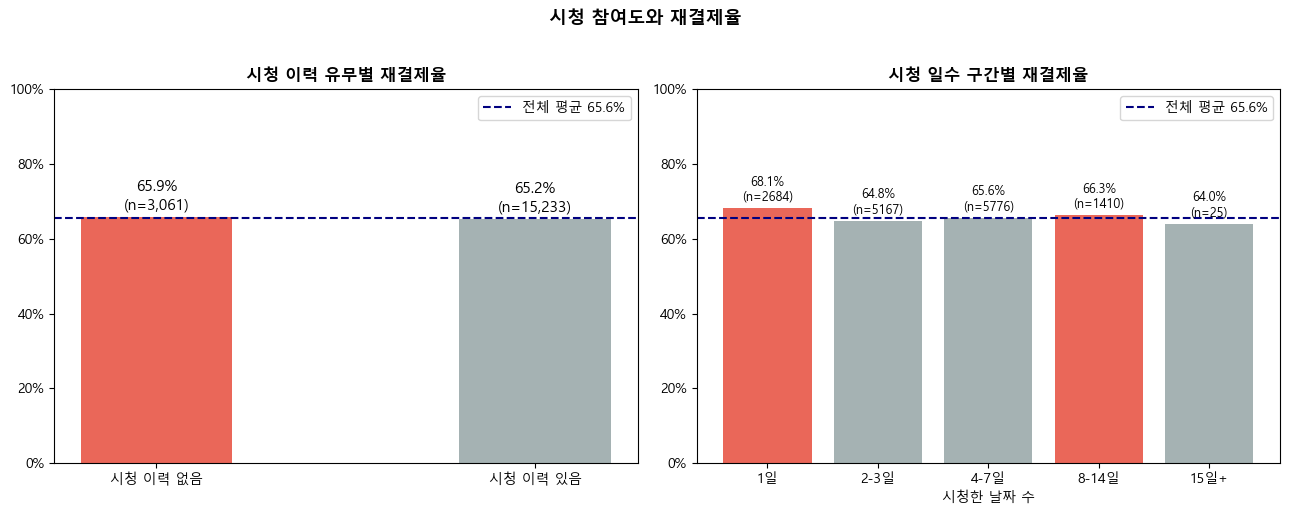

💡 인사이트: 시청 이력이 있는 유저의 재결제율이 더 높다면 → 첫 달 콘텐츠 경험 유도가 핵심


In [21]:
# View_History에 있는 유저 ID 목록
vh_user_ids = set(vh_mem['USER_ID'].unique())

# Membership 유저가 시청 이력이 있는지 여부
mem_um = mem2.merge(um, left_on='user_no', right_on='uid', how='left')
mem_um['has_watch'] = mem_um['USER_ID'].isin(vh_user_ids).map({True:'시청 이력 있음', False:'시청 이력 없음'})

watch_compare = (
    mem_um.groupby('has_watch')['repurchase_yn']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean':'rate', 'count':'cnt'})
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 왼쪽: 시청 이력 유무 × 재결제율
ax = axes[0]
colors = ['#e74c3c' if r > overall_rate else '#95a5a6' for r in watch_compare['rate']]
bars = ax.bar(watch_compare['has_watch'], watch_compare['rate'], color=colors, alpha=0.85, width=0.4)
ax.axhline(overall_rate, color='navy', linestyle='--', linewidth=1.5, label=f'전체 평균 {overall_rate:.1%}')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('시청 이력 유무별 재결제율', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend()
for bar, (_, row) in zip(bars, watch_compare.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{row['rate']:.1%}\n(n={row['cnt']:,})", ha='center', fontsize=11)

# 오른쪽: 시청일 수 × 재결제율
day_bins   = [0, 1, 3, 7, 14, 99]
day_labels = ['1일', '2-3일', '4-7일', '8-14일', '15일+']
user_stats['day_group'] = pd.cut(user_stats['watch_days'], bins=day_bins, labels=day_labels)
day_rate = (
    user_stats.groupby('day_group', observed=True)
    .agg(user_cnt=('USER_ID','count'), repurchase_rate=('repurchase_yn','mean'))
    .reset_index()
)

ax = axes[1]
colors3 = ['#e74c3c' if r > overall_rate else '#95a5a6' for r in day_rate['repurchase_rate']]
bars3 = ax.bar(day_rate['day_group'], day_rate['repurchase_rate'], color=colors3, alpha=0.85)
ax.axhline(overall_rate, color='navy', linestyle='--', linewidth=1.5, label=f'전체 평균 {overall_rate:.1%}')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('시청 일수 구간별 재결제율', fontsize=12, fontweight='bold')
ax.set_xlabel('시청한 날짜 수')
ax.set_ylim(0, 1)
ax.legend()
for bar, (_, row) in zip(bars3, day_rate.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{row['repurchase_rate']:.1%}\n(n={row['user_cnt']})", ha='center', fontsize=9)

plt.suptitle('시청 참여도와 재결제율', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('factor4_engagement.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 인사이트: 시청 이력이 있는 유저의 재결제율이 더 높다면 → 첫 달 콘텐츠 경험 유도가 핵심")


## 종합 인사이트 요약

In [22]:
print("=" * 60)
print("   재결제율을 높이기 위한 데이터 기반 전략 요약")
print("=" * 60)

rate_watch  = user_stats_all.groupby('watch_group', observed=True)['repurchase_yn'].mean()
rate_no_w   = watch_compare.loc[watch_compare['has_watch']=='시청 이력 없음', 'rate'].values[0]
rate_yes_w  = watch_compare.loc[watch_compare['has_watch']=='시청 이력 있음', 'rate'].values[0]

print(f"""
【분석 1】시청 행동
  → 영화를 많이 볼수록 재결제율 상승 경향
  → 가장 높은 구간: {rate_watch.idxmax()} ({rate_watch.max():.1%})
  전략: 신규 가입자에게 첫 달 '왓챠피디아 스타일' 추천 강화로 시청 유도

【분석 2】장르
  → 재결제율 상위 장르: {genre_rate.iloc[0]['genre']} ({genre_rate.iloc[0]['repurchase_rate']:.1%}),
                        {genre_rate.iloc[1]['genre']} ({genre_rate.iloc[1]['repurchase_rate']:.1%})
  전략: 해당 장르 콘텐츠 확보 및 해당 장르 선호 유저에게 우선 노출

【분석 3】프로모션·플랜
  → 플랜별 재결제율 차이 확인 → 업셀링 or 번들 구성 검토
  → 프로모션(100원) 유저의 재결제율이 낮다면 → 할인 의존 줄이고 콘텐츠로 유지

【분석 4】시청 참여도
  → 시청 이력 있음: {rate_yes_w:.1%}  /  없음: {rate_no_w:.1%}  (차이: {rate_yes_w - rate_no_w:+.1%})
  전략: 가입 후 첫 2주 내 최소 3편 이상 시청하도록 온보딩 알림·큐레이션 강화
""")
print("=" * 60)
print("모든 차트 저장 완료:")
for f in ['factor1_watch_behavior.png','factor2_genre.png',
          'factor3_promo_plan.png','factor4_engagement.png']:
    print(f"  {f}")


   재결제율을 높이기 위한 데이터 기반 전략 요약


KeyError: 'watch_group'

## 분석 5 · 100원 결제 유저 — 시청 행동별 재결제율

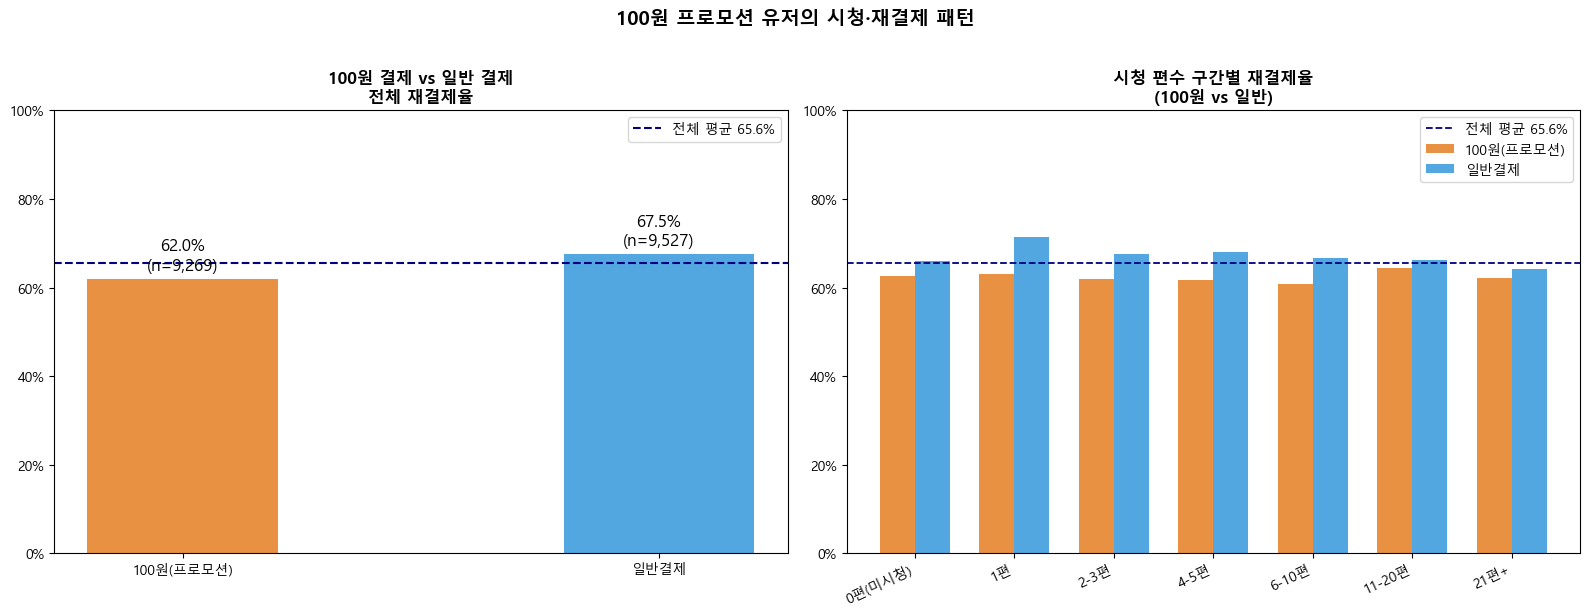

100원 결제 유저 재결제율 : 62.0%  (n=9,269명)
일반 결제 유저 재결제율  : 67.5%
차이                     : -5.5%

💡 100원 유저의 재결제율이 낮음
   → 할인 미끼로 유입된 후 이탈하는 패턴 가능성
   → 100원 유저 중 시청 편수가 많은 그룹은 재결제율이 올라가는지 확인 필요
   → 전략: 100원 유저에게 첫 달 적극적인 콘텐츠 추천 → 시청 습관 형성


In [ ]:
# ── 100원 여부 컬럼 추가 ──────────────────────────────────────
mem2['is_100won'] = (mem['amount'] == 100).map({True: '100원(프로모션)', False: '일반결제'})

# Membership → User_Mapping → user_stats_all 조인
mem_flag = mem2[['user_no', 'repurchase_yn', 'is_100won']].merge(
    um, left_on='user_no', right_on='uid', how='left'
)
user_all_flag = user_stats_all.merge(
    mem_flag[['USER_ID', 'is_100won']], on='USER_ID', how='left'
)
user_all_flag['is_100won'] = user_all_flag['is_100won'].fillna('일반결제')

overall_rate = mem['repurchase_yn'].mean()

# ── 차트 1: 100원 vs 일반 전체 재결제율 비교 ─────────────────
rate_100 = user_all_flag.groupby('is_100won')['repurchase_yn'].agg(['mean','count']).reset_index()
rate_100.columns = ['group','rate','cnt']

# ── 차트 2: 100원 vs 일반 × 시청 편수 구간 ───────────────────
group_100 = (
    user_all_flag.groupby(['is_100won', 'watch_group'], observed=True)['repurchase_yn']
    .mean()
    .reset_index()
    .rename(columns={'repurchase_yn': 'rate'})
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 전체 비교
ax = axes[0]
palette = {'100원(프로모션)': '#e67e22', '일반결제': '#3498db'}
colors_g = [palette[g] for g in rate_100['group']]
bars = ax.bar(rate_100['group'], rate_100['rate'], color=colors_g, alpha=0.85, width=0.4)
ax.axhline(overall_rate, color='navy', linestyle='--', linewidth=1.5,
           label=f'전체 평균 {overall_rate:.1%}')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('100원 결제 vs 일반 결제\n전체 재결제율', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend()
for bar, (_, row) in zip(bars, rate_100.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{row['rate']:.1%}\n(n={row['cnt']:,})", ha='center', fontsize=12)

# 오른쪽: 시청 편수 구간별 × 결제 유형
ax = axes[1]
groups = group_100['is_100won'].unique()
x = range(len(group_100['watch_group'].unique()))
width = 0.35
watch_labels = group_100['watch_group'].unique()

for i, grp in enumerate(groups):
    sub = group_100[group_100['is_100won'] == grp].set_index('watch_group').reindex(watch_labels)
    offset = (i - 0.5) * width
    bars = ax.bar([xi + offset for xi in x], sub['rate'].values,
                  width=width, label=grp, color=list(palette.values())[i], alpha=0.85)

ax.axhline(overall_rate, color='navy', linestyle='--', linewidth=1.3,
           label=f'전체 평균 {overall_rate:.1%}')
ax.set_xticks(list(x))
ax.set_xticklabels(watch_labels, rotation=25, ha='right')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('시청 편수 구간별 재결제율\n(100원 vs 일반)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend()

plt.suptitle('100원 프로모션 유저의 시청·재결제 패턴', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('factor5_100won.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 수치 요약 ──────────────────────────────────────────────────
r_100  = rate_100[rate_100['group']=='100원(프로모션)']['rate'].values[0]
r_norm = rate_100[rate_100['group']=='일반결제']['rate'].values[0]
n_100  = rate_100[rate_100['group']=='100원(프로모션)']['cnt'].values[0]

print(f"100원 결제 유저 재결제율 : {r_100:.1%}  (n={n_100:,}명)")
print(f"일반 결제 유저 재결제율  : {r_norm:.1%}")
print(f"차이                     : {r_100 - r_norm:+.1%}")
print()
if r_100 < r_norm:
    print("💡 100원 유저의 재결제율이 낮음")
    print("   → 할인 미끼로 유입된 후 이탈하는 패턴 가능성")
    print("   → 100원 유저 중 시청 편수가 많은 그룹은 재결제율이 올라가는지 확인 필요")
    print("   → 전략: 100원 유저에게 첫 달 적극적인 콘텐츠 추천 → 시청 습관 형성")
else:
    print("💡 100원 유저도 일반 유저만큼 재결제함")
    print("   → 프로모션이 장기 유지에 효과적 → 프로모션 지속 고려")
